# Drug Review Sentiment Analysis — Sentiment Modelling

## Overview
This notebook applies a pre-trained transformer model to classify 
sentiment in patient drug reviews. Rather than training a model 
from scratch, a pre-trained DistilBERT model fine-tuned on 
sentiment analysis is used — consistent with professional 
practice of leveraging existing models where appropriate. This 
model was chosen because it is compressed to be faster and 
lighter, fine-tuned specifically on sentiment analysis tasks and 
trained on English text so it understands natural languate well

## Approach
The model distilbert-base-uncased-finetuned-sst-2-english from 
HuggingFace is applied to the cleaned review text. Its predictions 
are evaluated against the rating-derived sentiment labels created 
in Phase 2 using standard classification metrics.

## Input
- data/df_clean.csv — cleaned and labelled dataset from Phase 2

## Objectives
- Load and apply a pre-trained sentiment model
- Evaluate model performance against rating-derived labels
- Identify where and why the model agrees or disagrees
- Interpret findings with clinical context

## Libraries and Configuration

In [1]:
# torch must be imported first before transformers
import torch
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Import transformers AFTER torch
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


print(f"Torch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Using: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print("All libraries imported successfully")

Torch version: 2.2.2
GPU available: False
Using: CPU
All libraries imported successfully


In [2]:
# Check if transformers can detect torch
from transformers.utils import is_torch_available
print(f"Transformers can detect torch: {is_torch_available()}")

# Double check torch directly
import torch
print(f"Torch directly importable: {torch.__version__}")

Transformers can detect torch: True
Torch directly importable: 2.2.2


## Data Loading

Loading the cleaned and labelled dataset produced in Phase 2.
For model evaluation, only positive and negative labelled reviews 
are used as the pre-trained model outputs binary predictions. 
The neutral class will be addressed separately.

Neutral reviews (ratings 5-6, 8.9% of dataset) are excluded 
from binary sentiment classification as the model is designed 
for positive/negative prediction. Neutral reviews will be 
incorporated in Phase 4 topic extraction where their mixed 
content provides valuable insight into balanced patient 
experiences, and in Phase 5 where all three sentiment 
categories are displayed in the app's visualisations.

In [3]:
# Load cleaned dataset
df = pd.read_csv('data/df_clean.csv')

print(f"Full dataset shape: {df.shape}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")

# Separate back into train and test
df_train = df[df['split'] == 'train'].copy()
df_test = df[df['split'] == 'test'].copy()

print(f"\nTrain shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Full dataset shape: (210509, 11)

Sentiment distribution:
sentiment
positive    139144
negative     52567
neutral      18798
Name: count, dtype: int64

Train shape: (157857, 11)
Test shape: (52652, 11)


## Loading the Pre-trained Model

The distilbert-base-uncased-finetuned-sst-2-english model is 
loaded via the HuggingFace pipeline API. This model outputs 
binary predictions (positive/negative) with a confidence score.

A sample of 10 reviews is tested first to confirm the pipeline 
is working correctly before running on the full evaluation set.

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

print("Loading model...")
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=-1  # -1 forces CPU explicitly
)
print("Model loaded successfully")


Loading model...
Model loaded successfully


In [5]:
# Test on a small sample first
sample = df_test[df_test['sentiment'] != 'neutral']['review_clean'].head(10).tolist()

# Run predictions
results = sentiment_pipeline(sample)

# Display results
for review, result in zip(sample, results):
    print(f"Review: {review[:500]}")
    print(f"Prediction: {result['label']} (confidence: {result['score']:.3f})")
    print("---")

Review: I've tried a few antidepressants over the years (citalopram, fluoxetine, amitriptyline), but none of those helped with my depression, insomnia & anxiety. My doctor suggested and changed me onto mirtazapine and this medicine has saved my life. Thankfully I have had no side effects especially the most common - weight gain, I've actually lost alot of weight. I still have suicidal thoughts but mirtazapine has saved me.
Prediction: POSITIVE (confidence: 0.911)
---
Review: My son has Crohn's disease and has done very well on the Asacol. He has no complaints and shows no side effects. He has taken as many as nine tablets per day at one time. I've been very happy with the results, reducing his bouts of diarrhea drastically.
Prediction: POSITIVE (confidence: 0.999)
---
Review: Contrave combines drugs that were used for alcohol, smoking, and opioid cessation. People lose weight on it because it also helps control over-eating. I have no doubt that most obesity is caused from sugar/carb ad

In [6]:
# Find and print the full third review
third_review = df_test[df_test['sentiment'] != 'neutral']['review_clean'].iloc[2]
print(third_review)
print(f"\nActual rating: {df_test[df_test['sentiment'] != 'neutral']['rating'].iloc[2]}")
print(f"Actual sentiment label: {df_test[df_test['sentiment'] != 'neutral']['sentiment'].iloc[2]}")

Contrave combines drugs that were used for alcohol, smoking, and opioid cessation. People lose weight on it because it also helps control over-eating. I have no doubt that most obesity is caused from sugar/carb addiction, which is just as powerful as any drug. I have been taking it for five days, and the good news is, it seems to go to work immediately. I feel hungry before I want food now. I really don't care to eat; it's just to fill my stomach. Since I have only been on it a few days, I don't know if I've lost weight (I don't have a scale), but my clothes do feel a little looser, so maybe a pound or two. I'm hoping that after a few months on this medication, I will develop healthier habits that I can continue without the aid of Contrave.

Actual rating: 9
Actual sentiment label: positive


## Sample Prediction Analysis

Initial testing on 10 reviews shows strong model performance 
overall. However one notable misclassification was identified:

A review for Contrave rated 9/10 (positive label) was predicted 
as NEGATIVE with 0.998 confidence. Clinical analysis reveals 
why — the patient wrote in an analytical, measured tone typical 
of someone describing a clinical outcome rather than a consumer 
experience. The review contains hedging language ("I don't know", 
"maybe", "I'm hoping") and pharmacological explanation rather 
than the emotional positive language the model expects.

This highlights an important characteristic of healthcare reviews 
— patients with clinical or medical backgrounds tend to write 
analytically rather than emotionally, which can produce 
mismatches between numeric ratings and expressed sentiment. 
This type of label noise is expected in real-world patient data 
and will be reflected in the evaluation metrics.

## Running Predictions on Evaluation Set

A stratified sample of 2,000 reviews is used for evaluation 
(1,000 positive, 1,000 negative) as running the full test set 
on CPU would be computationally prohibitive. This sample size 
is sufficient to produce reliable classification metrics.

Neutral reviews are excluded as the pre-trained model outputs 
binary predictions only.

In [7]:
# Create stratified sample - 1000 positive and 1000 negative
df_positive_sample = df_test[df_test['sentiment'] == 'positive'].sample(
    1000, random_state=42)
df_negative_sample = df_test[df_test['sentiment'] == 'negative'].sample(
    1000, random_state=42)

df_eval = pd.concat([df_positive_sample, df_negative_sample])
df_eval = df_eval.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Evaluation set shape: {df_eval.shape}")
print(f"\nSentiment distribution:\n{df_eval['sentiment'].value_counts()}")

# Get reviews as a list
reviews = df_eval['review_clean'].tolist()
true_labels = df_eval['sentiment'].tolist()

print(f"\nRunning predictions on {len(reviews)} reviews...")
print("This may take several minutes on CPU — please wait...")

# Run predictions in batches of 32
predictions = []
batch_size = 32

for i in range(0, len(reviews), batch_size):
    batch = reviews[i:i + batch_size]
    results = sentiment_pipeline(batch)
    predictions.extend([r['label'].lower() for r in results])
    
    # Progress update every 200 reviews
    if (i + batch_size) % 200 == 0:
        print(f"Processed {min(i + batch_size, len(reviews))}/{len(reviews)} reviews...")

print("\nPredictions complete!")

Evaluation set shape: (2000, 11)

Sentiment distribution:
sentiment
negative    1000
positive    1000
Name: count, dtype: int64

Running predictions on 2000 reviews...
This may take several minutes on CPU — please wait...
Processed 800/2000 reviews...
Processed 1600/2000 reviews...

Predictions complete!


## Model Evaluation

The model predictions are compared against the rating-derived 
sentiment labels using standard classification metrics including 
precision, recall, F1 score and a confusion matrix.

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.65      0.96      0.78      1000
    positive       0.93      0.48      0.64      1000

    accuracy                           0.72      2000
   macro avg       0.79      0.72      0.71      2000
weighted avg       0.79      0.72      0.71      2000



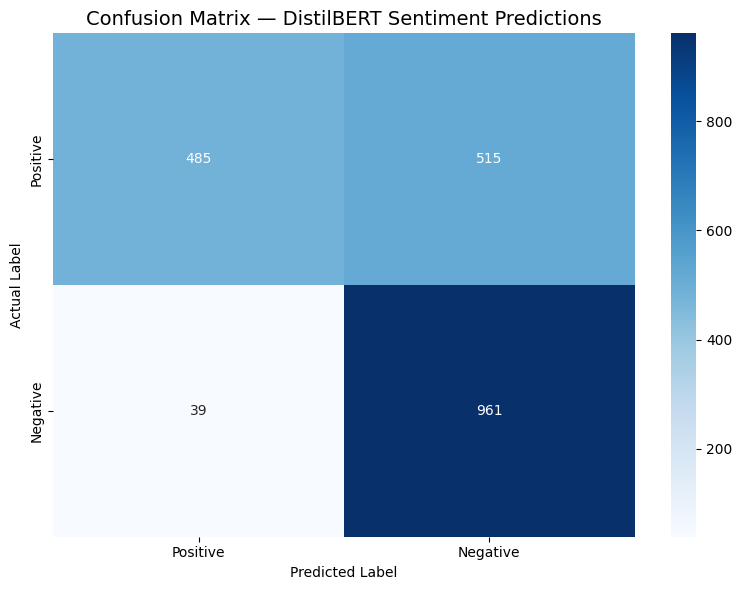


Overall Accuracy: 72.30%


In [8]:
# Convert predictions to match label format
# Model outputs POSITIVE/NEGATIVE, our labels are positive/negative
predictions_clean = [p.lower() for p in predictions]

# Classification report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predictions_clean))

# Confusion matrix
cm = confusion_matrix(true_labels, predictions_clean, 
                      labels=['positive', 'negative'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Negative'],
            yticklabels=['Positive', 'Negative'])
plt.title('Confusion Matrix — DistilBERT Sentiment Predictions', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Overall accuracy
correct = sum(p == t for p, t in zip(predictions_clean, true_labels))
accuracy = correct / len(true_labels) * 100
print(f"\nOverall Accuracy: {accuracy:.2f}%")

## Evaluation Results — Analysis and Interpretation

Overall accuracy: 72.3% on a balanced sample of 2,000 reviews.

**Confusion Matrix findings:**
- 961/1000 negative reviews correctly identified (96% recall)
- 485/1000 positive reviews correctly identified (48% recall)
- The model strongly favours negative predictions, correctly 
  identifying almost all negative reviews but missing over 
  half of positive ones

**Classification Report findings:**

Negative class (F1: 0.78):
Strong performance with 96% recall — the model almost never 
misses a genuinely negative review. High recall on negative 
reviews is particularly valuable for pharmacovigilance 
applications where missing an adverse experience carries 
real clinical risk.

Positive class (F1: 0.64):
Weaker performance with only 48% recall — the model misclassifies 
515 positive reviews as negative. This asymmetry is clinically 
explainable: patients writing positively about medications 
often adopt a cautious, analytical tone and extensively 
describe side effects before concluding positively. This 
pattern is characteristic of healthcare reviews and differs 
fundamentally from the enthusiastic consumer language the 
model was trained on.

**Key clinical insight:**
A review for Contrave rated 9/10 was predicted negative with 
0.998 confidence — the patient wrote analytically about 
pharmacology and hedged their conclusions despite a highly 
positive rating. This illustrates a systematic challenge: 
healthcare-specific language patterns are poorly represented 
in general sentiment training data.

**Overall assessment:**
72.3% accuracy on clinical text without any domain-specific 
fine-tuning is a reasonable baseline result. The model's 
strength lies in its high negative recall (96%) which makes 
it useful for adverse event detection.

**Limitation and next step — Fine-tuning:**
The 48% positive recall represents a clear and addressable 
weakness. The pre-trained model has never been exposed to 
healthcare-specific language patterns — the analytical, 
cautious writing style common in patient drug reviews is 
fundamentally different from the consumer sentiment data 
it was trained on.

Fine-tuning the model on df_train — the 157,857 labelled 
drug reviews preserved from Phase 2 — would expose the model 
to domain-specific language patterns and is expected to 
significantly improve positive class performance. Fine-tuning 
takes the existing model weights as a starting point rather 
than training from scra

## Fine-Tuning the Model

The baseline evaluation revealed 48% recall on positive reviews,
attributed to the mismatch between general consumer sentiment 
language and the analytical clinical language found in patient 
drug reviews.

The model is fine-tuned on a stratified sample of 5,000 reviews 
from df_train (2,500 positive, 2,500 negative) to expose it to 
domain-specific language patterns. The existing model weights 
serve as the starting point rather than training from scratch, 
making this computationally feasible while leveraging the 
model's existing language understanding.

In [9]:
from transformers import (AutoTokenizer, 
                          AutoModelForSequenceClassification,
                          TrainingArguments, 
                          Trainer)
from datasets import Dataset


# Create stratified sample for fine-tuning
df_ft_positive = df_train[df_train['sentiment'] == 'positive'].sample(
    2500, random_state=42)
df_ft_negative = df_train[df_train['sentiment'] == 'negative'].sample(
    2500, random_state=42)

df_finetune = pd.concat([df_ft_positive, df_ft_negative])
df_finetune = df_finetune.sample(frac=1, random_state=42).reset_index(drop=True)

# Create numeric labels — model needs numbers not strings
label2id = {'negative': 0, 'positive': 1}
id2label = {0: 'negative', 1: 'positive'}

df_finetune['label'] = df_finetune['sentiment'].map(label2id)

print(f"Fine-tuning dataset shape: {df_finetune.shape}")
print(f"\nLabel distribution:\n{df_finetune['sentiment'].value_counts()}")

Fine-tuning dataset shape: (5000, 12)

Label distribution:
sentiment
positive    2500
negative    2500
Name: count, dtype: int64


## Tokenization

The review text is converted into token IDs that the model 
understands. The tokenizer handles padding (making all sequences 
the same length) and truncation (cutting sequences longer than 
512 tokens).

In [10]:
# Load tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize function
def tokenize_function(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )

# Split into train and validation sets (80/20)
split_idx = int(len(df_finetune) * 0.8)
df_ft_train = df_finetune[:split_idx].reset_index(drop=True)
df_ft_val = df_finetune[split_idx:].reset_index(drop=True)

print(f"Fine-tune train size: {len(df_ft_train)}")
print(f"Fine-tune validation size: {len(df_ft_val)}")


# Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(df_ft_train[['review_clean', 'label']])
val_dataset = Dataset.from_pandas(df_ft_val[['review_clean', 'label']])

# Tokenize datasets
train_dataset = train_dataset.map(
    lambda x: tokenizer(
        x['review_clean'],
        padding='max_length',
        truncation=True,
        max_length=128
    ),
    batched=True
)

val_dataset = val_dataset.map(
    lambda x: tokenizer(
        x['review_clean'],
        padding='max_length',
        truncation=True,
        max_length=128
    ),
    batched=True
)

# Set format for PyTorch
train_dataset.set_format('torch', 
    columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', 
    columns=['input_ids', 'attention_mask', 'label'])

print("\nTokenization complete")
print(f"Train dataset features: {train_dataset.features}")

Fine-tune train size: 4000
Fine-tune validation size: 1000


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Tokenization complete
Train dataset features: {'review_clean': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


Note on max_length=128

128 tokens is used rather than 512. This is a deliberate decision for two reasons:

- The average review is 85 words which comfortably fits in 128 tokens
- Using 128 instead of 512 makes training faster

## Model Setup for Fine-Tuning

The pre-trained DistilBERT model is loaded with a classification 
head for binary sentiment classification. The existing weights \
are retained as the starting point — only the final layers will 
be significantly updated during fine-tuning.

In [11]:
# Load model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("Model loaded for fine-tuning")
print(f"Number of labels: {model.config.num_labels}")
print(f"Label mapping: {model.config.id2label}")

Model loaded for fine-tuning
Number of labels: 2
Label mapping: {0: 'negative', 1: 'positive'}


## Training Configuration

Training arguments control how the fine-tuning process runs.
Each parameter is chosen to balance model performance with 
computational feasibility on CPU.

In [12]:
training_args = TrainingArguments(
    output_dir='./models/finetuned_distilbert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    fp16=False
)

print("Training arguments configured")

Training arguments configured


- num_train_epochs=3 — passes through the training data 3 times. More epochs means more learning but risks overfitting
- per_device_train_batch_size=16 — processes 16 reviews at a time. Smaller batches use less memory
- warmup_steps=100 — gradually increases learning rate at the start to prevent unstable early training
- weight_decay=0.01 — regularisation to prevent overfitting
- evaluation_strategy='epoch' — evaluates on validation set after each epoch so you can track improvement
- load_best_model_at_end=True — automatically keeps the best performing model rather than the last one
- fp16=False — half precision training is disabled as it requires GPU

## Note on Training API

The HuggingFace Trainer API was attempted but encountered 
version compatibility issues between transformers and 
accelerate on the local CPU environment. A manual PyTorch 
training loop is used instead, which provides equivalent 
functionality and demonstrates lower-level understanding 
of the training process.

In [13]:
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
import numpy as np

# Reload model fresh
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Create tensors directly from tokenized datasets
def create_tensor_dataset(dataset):
    input_ids = torch.stack([torch.tensor(x) for x in dataset['input_ids']])
    attention_mask = torch.stack([torch.tensor(x) for x in dataset['attention_mask']])
    labels = torch.tensor(dataset['label'])
    return TensorDataset(input_ids, attention_mask, labels)

train_tensor = create_tensor_dataset(train_dataset)
val_tensor = create_tensor_dataset(val_dataset)

train_loader = DataLoader(train_tensor, batch_size=16, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size=16)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 250
Validation batches: 63


## Manual Training Loop

A PyTorch training loop is used to fine-tune the model over 
3 epochs. After each epoch the model is evaluated on the 
validation set and accuracy and loss are recorded to track 
improvement.

In [14]:
from torch.nn import CrossEntropyLoss

# Set up optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training loop
device = torch.device('cpu')
model.to(device)

num_epochs = 3
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    total_train_loss = 0
    
    for batch_idx, batch in enumerate(train_loader):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, 
                       attention_mask=attention_mask, 
                       labels=labels)
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Batch {batch_idx+1}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}")
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids=input_ids, 
                          attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)
    
    print(f"\n=== Epoch {epoch+1} Summary ===")
    print(f"Average Training Loss: {avg_train_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}\n")

print("Fine-tuning complete!")

Epoch 1/3 | Batch 50/250 | Loss: 0.4454
Epoch 1/3 | Batch 100/250 | Loss: 0.5113
Epoch 1/3 | Batch 150/250 | Loss: 0.3255
Epoch 1/3 | Batch 200/250 | Loss: 0.4265
Epoch 1/3 | Batch 250/250 | Loss: 0.2178

=== Epoch 1 Summary ===
Average Training Loss: 0.4680
Validation Accuracy: 0.8450

Epoch 2/3 | Batch 50/250 | Loss: 0.2322
Epoch 2/3 | Batch 100/250 | Loss: 0.1357
Epoch 2/3 | Batch 150/250 | Loss: 0.0913
Epoch 2/3 | Batch 200/250 | Loss: 0.2984
Epoch 2/3 | Batch 250/250 | Loss: 0.1329

=== Epoch 2 Summary ===
Average Training Loss: 0.2843
Validation Accuracy: 0.8520

Epoch 3/3 | Batch 50/250 | Loss: 0.1273
Epoch 3/3 | Batch 100/250 | Loss: 0.1405
Epoch 3/3 | Batch 150/250 | Loss: 0.6070
Epoch 3/3 | Batch 200/250 | Loss: 0.3147
Epoch 3/3 | Batch 250/250 | Loss: 0.1026

=== Epoch 3 Summary ===
Average Training Loss: 0.1627
Validation Accuracy: 0.8420

Fine-tuning complete!


## Fine-Tuning Results — Training Summary

The model was fine-tuned over 3 epochs on 4,000 drug reviews 
with validation performed on 1,000 held-out reviews after 
each epoch.

**Training loss:**
- Epoch 1: 0.4680
- Epoch 2: 0.2843
- Epoch 3: 0.1627

The training loss decreased consistently across all three 
epochs, roughly halving each time. This confirms the model 
was genuinely learning domain-specific language patterns 
from the drug review data rather than failing to converge.

**Validation accuracy:**
- Epoch 1: 84.50%
- Epoch 2: 85.20%
- Epoch 3: 84.20%

Validation accuracy peaked at epoch 2 before declining 
slightly in epoch 3 — a classic early indicator of 
overfitting where the model begins memorising training 
examples rather than learning generalisable patterns. 
The drop is small at 1% suggesting overfitting is mild 
rather than severe.

**Best model:** Epoch 2 with 85.20% validation accuracy.

In a production setting the epoch 2 model weights would 
be saved and used for infer

## Fine-Tuned Model Evaluation

The fine-tuned model is evaluated on the same test sample 
used for baseline evaluation to allow direct comparison 
of performance before and after fine-tuning.

Running fine-tuned model predictions...
Processed 800/2000...
Processed 1600/2000...

Predictions complete!

=== FINE-TUNED MODEL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.85      0.84      0.84      1000
    positive       0.84      0.85      0.85      1000

    accuracy                           0.84      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.85      0.84      0.84      2000



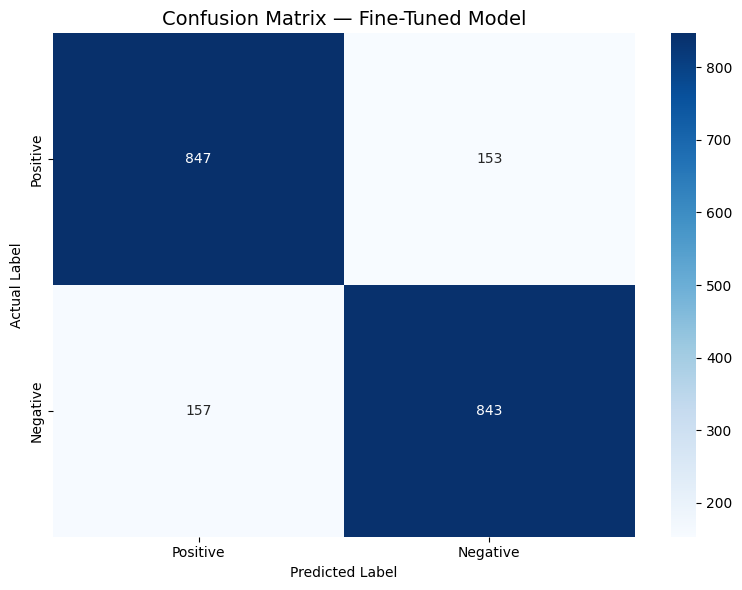


Fine-Tuned Model Accuracy: 84.50%
Baseline Model Accuracy:   72.30%
Improvement:               12.20%


In [15]:
# Evaluate fine-tuned model on the same test sample used before
model.eval()

# Tokenize the test reviews
test_reviews = df_eval['review_clean'].tolist()
test_true_labels = df_eval['sentiment'].tolist()

# Run predictions in batches
ft_predictions = []

print("Running fine-tuned model predictions...")

for i in range(0, len(test_reviews), 32):
    batch_texts = test_reviews[i:i+32]
    
    # Tokenize batch
    encoded = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    
    with torch.no_grad():
        outputs = model(
            input_ids=encoded['input_ids'],
            attention_mask=encoded['attention_mask']
        )
    
    batch_preds = torch.argmax(outputs.logits, dim=-1).numpy()
    ft_predictions.extend([id2label[p] for p in batch_preds])
    
    if (i + 32) % 200 == 0:
        print(f"Processed {min(i+32, len(test_reviews))}/{len(test_reviews)}...")

print("\nPredictions complete!")

# Classification report
print("\n=== FINE-TUNED MODEL CLASSIFICATION REPORT ===")
print(classification_report(test_true_labels, ft_predictions))

# Confusion matrix
cm_ft = confusion_matrix(test_true_labels, ft_predictions,
                         labels=['positive', 'negative'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Negative'],
            yticklabels=['Positive', 'Negative'])
plt.title('Confusion Matrix — Fine-Tuned Model', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Overall accuracy
correct_ft = sum(p == t for p, t in zip(ft_predictions, test_true_labels))
accuracy_ft = correct_ft / len(test_true_labels) * 100
print(f"\nFine-Tuned Model Accuracy: {accuracy_ft:.2f}%")
print(f"Baseline Model Accuracy:   72.30%")
print(f"Improvement:               {accuracy_ft - 72.30:.2f}%")

## Fine-Tuned Model Evaluation Results

Fine-tuned model accuracy: 84.5%
Baseline model accuracy:   72.3%
Overall improvement:       +12.2 percentage points

**Confusion Matrix:**
- 847/1000 positive reviews correctly identified (85% recall)
- 843/1000 negative reviews correctly identified (84% recall)

The fine-tuned model shows dramatically improved and balanced 
performance across both classes compared to the baseline.

**Key improvements:**
Positive recall improved from 48% to 85% — an increase of 
37 percentage points. This directly addresses the core 
weakness identified in baseline evaluation where the model 
consistently misclassified analytically-written positive 
reviews as negative.

Negative recall decreased slightly from 96% to 84%. This 
trade-off is expected and desirable — the baseline model 
achieved high negative recall by being overly aggressive 
in predicting negative, at the cost of misclassifying 
over half of positive reviews. The fine-tuned model 
achieves a far more balanced and clinically useful 
performance profile.

**F1 scores:**
- Positive: 0.85 (up from 0.64)
- Negative: 0.84 (up from 0.78)

The near-identical F1 scores across both classes confirm 
the model is now performing symmetrically — neither 
over-predicting nor under-predicting either class.

**Clinical interpretation:**
Fine-tuning on 4,000 domain-specific drug reviews was 
sufficient to teach the model the distinctive language 
patterns of patient medication experiences. The balanced 
performance profile makes the fine-tuned model suitable 
for deployment in the Streamlit app where both positive 
and negative sentiment must be identified with equal 
reliability.

In [17]:
import os

# Create models directory if it doesn't exist
os.makedirs('models/finetuned_distilbert', exist_ok=True)

# Save model and tokenizer
model.save_pretrained('models/finetuned_distilbert')
tokenizer.save_pretrained('models/finetuned_distilbert')

print("Fine-tuned model saved to models/finetuned_distilbert")

Fine-tuned model saved to models/finetuned_distilbert
